# SciPy Distributions Reference

A comprehensive catalog of **all probability distributions** available in `scipy.stats`.

| Category | Count | Base class |
|---|---|---|
| **Discrete** | 21 | `rv_discrete` |
| **Continuous** | 100+ | `rv_continuous` |
| **Multivariate** | 17 | (various) |

**Source**: [scipy.stats documentation](https://docs.scipy.org/doc/scipy/reference/stats.html)

---

## Common API for univariate distributions

Every `rv_continuous` / `rv_discrete` instance exposes the same methods:

| Method | Description |
|---|---|
| `rvs(size=n)` | Draw `n` random samples |
| `pdf(x)` / `pmf(k)` | Probability density / mass function |
| `cdf(x)` | Cumulative distribution function $P(X \le x)$ |
| `sf(x)` | Survival function $1 - \text{CDF}(x)$ |
| `ppf(q)` | Percent-point (inverse CDF) at quantile $q$ |
| `isf(q)` | Inverse survival function |
| `mean()` | Expected value |
| `var()` | Variance |
| `std()` | Standard deviation |
| `median()` | Median |
| `interval(confidence)` | Equal-tail confidence interval |
| `entropy()` | Differential / discrete entropy |
| `fit(data)` | MLE parameter estimation (continuous only) |
| `expect(func)` | $E[f(X)]$ via numerical integration |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11})

---

## 1 · Discrete Distributions

Subclasses of `rv_discrete`. Use `.pmf(k)` for the probability mass function.

| # | `scipy.stats` name | Distribution | Parameters | Support |
|---|---|---|---|---|
| 1 | `bernoulli` | Bernoulli | $p$ | $\{0, 1\}$ |
| 2 | `binom` | Binomial | $n, p$ | $\{0, 1, \dots, n\}$ |
| 3 | `betabinom` | Beta-Binomial | $n, a, b$ | $\{0, 1, \dots, n\}$ |
| 4 | `betanbinom` | Beta-Negative Binomial | $n, a, b$ | $\{0, 1, 2, \dots\}$ |
| 5 | `geom` | Geometric | $p$ | $\{1, 2, 3, \dots\}$ |
| 6 | `nbinom` | Negative Binomial | $n, p$ | $\{0, 1, 2, \dots\}$ |
| 7 | `hypergeom` | Hypergeometric | $M, n, N$ | $\{\max(0,N-M+n), \dots, \min(n,N)\}$ |
| 8 | `nhypergeom` | Negative Hypergeometric | $M, n, r$ | $\{0, 1, \dots, M-n\}$ |
| 9 | `nchypergeom_fisher` | Fisher's Noncentral Hypergeometric | $M, n, N, \omega$ | subset of integers |
| 10 | `nchypergeom_wallenius` | Wallenius' Noncentral Hypergeometric | $M, n, N, \omega$ | subset of integers |
| 11 | `poisson` | Poisson | $\mu$ | $\{0, 1, 2, \dots\}$ |
| 12 | `poisson_binom` | Poisson Binomial | $p_1, \dots, p_n$ | $\{0, 1, \dots, n\}$ |
| 13 | `planck` | Planck (discrete exponential) | $\lambda$ | $\{0, 1, 2, \dots\}$ |
| 14 | `boltzmann` | Boltzmann (truncated discrete exponential) | $\lambda, N$ | $\{0, 1, \dots, N-1\}$ |
| 15 | `randint` | Discrete Uniform | $\text{low}, \text{high}$ | $\{\text{low}, \dots, \text{high}-1\}$ |
| 16 | `dlaplace` | Discrete Laplace | $a$ | $\{\dots, -2, -1, 0, 1, 2, \dots\}$ |
| 17 | `logser` | Logarithmic (Log-Series) | $p$ | $\{1, 2, 3, \dots\}$ |
| 18 | `skellam` | Skellam | $\mu_1, \mu_2$ | $\{\dots, -2, -1, 0, 1, 2, \dots\}$ |
| 19 | `yulesimon` | Yule–Simon | $\alpha$ | $\{1, 2, 3, \dots\}$ |
| 20 | `zipf` | Zipf (Zeta) | $a$ | $\{1, 2, 3, \dots\}$ |
| 21 | `zipfian` | Zipfian | $a, n$ | $\{1, 2, \dots, n\}$ |

In [2]:
# Programmatically list all discrete distributions
discrete_dists = [
    ('bernoulli',    'Bernoulli',                  dict(p=0.3)),
    ('binom',        'Binomial',                   dict(n=10, p=0.5)),
    ('betabinom',    'Beta-Binomial',              dict(n=10, a=2, b=3)),
    ('betanbinom',   'Beta-Negative Binomial',     dict(n=5, a=2, b=3)),
    ('geom',         'Geometric',                  dict(p=0.3)),
    ('nbinom',       'Negative Binomial',          dict(n=5, p=0.5)),
    ('hypergeom',    'Hypergeometric',             dict(M=50, n=10, N=15)),
    ('nhypergeom',   'Negative Hypergeometric',    dict(M=50, n=10, r=5)),
    ('nchypergeom_fisher',    "Fisher's NC HGeom", dict(M=50, n=10, N=15, odds=2)),
    ('nchypergeom_wallenius', "Wallenius' NC HGeom", dict(M=50, n=10, N=15, odds=2)),
    ('poisson',      'Poisson',                    dict(mu=5)),
    ('planck',       'Planck',                     dict(lambda_=1.5)),
    ('boltzmann',    'Boltzmann',                  dict(lambda_=1.5, N=10)),
    ('randint',      'Discrete Uniform',           dict(low=0, high=10)),
    ('dlaplace',     'Discrete Laplace',           dict(a=0.5)),
    ('logser',       'Logarithmic',                dict(p=0.9)),
    ('skellam',      'Skellam',                    dict(mu1=5, mu2=3)),
    ('yulesimon',    'Yule-Simon',                 dict(alpha=3)),
    ('zipf',         'Zipf',                       dict(a=2.5)),
    ('zipfian',      'Zipfian',                    dict(a=2.5, n=20)),
]

print(f"{'scipy name':<28} {'Distribution':<28} {'Mean':>10} {'Var':>12}")
print("-" * 82)
for name, label, params in discrete_dists:
    try:
        rv = getattr(stats, name)(**params)
        m, v = rv.mean(), rv.var()
        print(f"{name:<28} {label:<28} {m:10.4f} {v:12.4f}")
    except Exception as e:
        print(f"{name:<28} {label:<28} {'(error)':>10} {str(e)[:20]}")

scipy name                   Distribution                       Mean          Var
----------------------------------------------------------------------------------
bernoulli                    Bernoulli                        0.3000       0.2100
binom                        Binomial                         5.0000       2.5000
betabinom                    Beta-Binomial                    4.0000       6.0000
betanbinom                   Beta-Negative Binomial          15.0000          inf
geom                         Geometric                        3.3333       7.7778
nbinom                       Negative Binomial                5.0000      10.0000
hypergeom                    Hypergeometric                   3.0000       1.7143
nhypergeom                   Negative Hypergeometric          1.2195       1.3002
nchypergeom_fisher           Fisher's NC HGeom                4.2684       1.9103
nchypergeom_wallenius        Wallenius' NC HGeom              4.5583       1.9298
poisson        

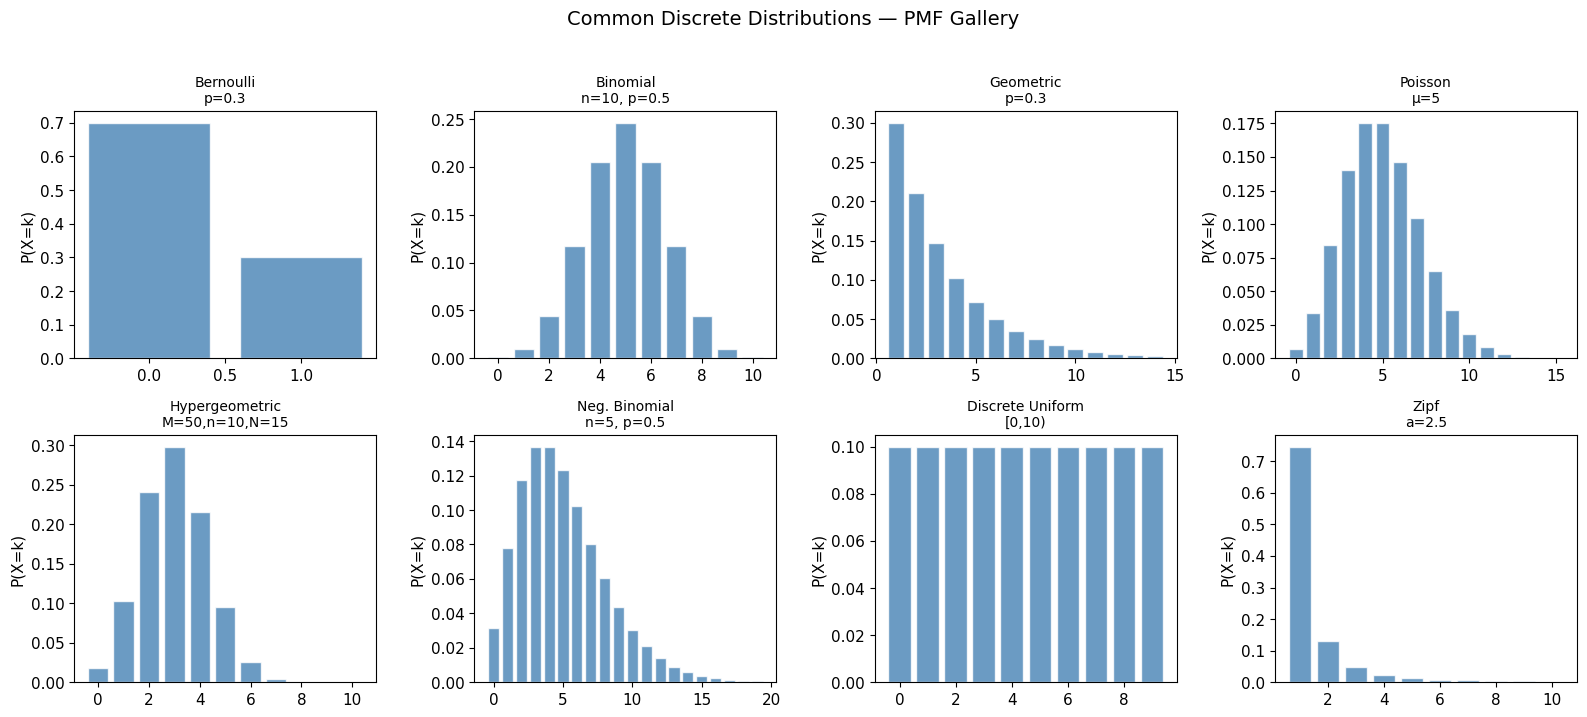

In [3]:
# Visual gallery: PMFs of the most common discrete distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

gallery = [
    ('Bernoulli\np=0.3',       stats.bernoulli(p=0.3),     np.arange(0, 2)),
    ('Binomial\nn=10, p=0.5',  stats.binom(n=10, p=0.5),   np.arange(0, 11)),
    ('Geometric\np=0.3',       stats.geom(p=0.3),           np.arange(1, 15)),
    ('Poisson\nμ=5',           stats.poisson(mu=5),         np.arange(0, 16)),
    ('Hypergeometric\nM=50,n=10,N=15', stats.hypergeom(M=50, n=10, N=15), np.arange(0, 11)),
    ('Neg. Binomial\nn=5, p=0.5', stats.nbinom(n=5, p=0.5), np.arange(0, 20)),
    ('Discrete Uniform\n[0,10)', stats.randint(low=0, high=10), np.arange(0, 10)),
    ('Zipf\na=2.5',            stats.zipf(a=2.5),           np.arange(1, 11)),
]

for ax, (title, rv, k) in zip(axes, gallery):
    ax.bar(k, rv.pmf(k), color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('P(X=k)')

plt.suptitle('Common Discrete Distributions — PMF Gallery', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 2 · Continuous Distributions

Subclasses of `rv_continuous`. Use `.pdf(x)` for the probability density function.

### 2.1 — Most commonly used

| # | `scipy.stats` name | Distribution | Parameters | Support |
|---|---|---|---|---|
| 1 | `norm` | Normal (Gaussian) | $\mu, \sigma$ | $(-\infty, \infty)$ |
| 2 | `uniform` | Uniform | $a, b$ | $[a, a+b]$ |
| 3 | `expon` | Exponential | $\lambda$ (via `scale=1/λ`) | $[0, \infty)$ |
| 4 | `gamma` | Gamma | $\alpha, \beta$ | $[0, \infty)$ |
| 5 | `beta` | Beta | $a, b$ | $[0, 1]$ |
| 6 | `chi2` | Chi-squared | $k$ (df) | $[0, \infty)$ |
| 7 | `t` | Student's t | $\nu$ (df) | $(-\infty, \infty)$ |
| 8 | `f` | F (Fisher–Snedecor) | $d_1, d_2$ | $[0, \infty)$ |
| 9 | `lognorm` | Log-Normal | $s=\sigma$ | $(0, \infty)$ |
| 10 | `weibull_min` | Weibull (minimum) | $c$ | $[0, \infty)$ |
| 11 | `pareto` | Pareto | $b$ | $[1, \infty)$ |
| 12 | `cauchy` | Cauchy | — | $(-\infty, \infty)$ |
| 13 | `laplace` | Laplace | — | $(-\infty, \infty)$ |
| 14 | `logistic` | Logistic | — | $(-\infty, \infty)$ |
| 15 | `rayleigh` | Rayleigh | — | $[0, \infty)$ |
| 16 | `erlang` | Erlang | $a$ (integer shape) | $[0, \infty)$ |
| 17 | `truncnorm` | Truncated Normal | $a, b$ (standardised bounds) | $[a, b]$ |

### 2.2 — Full catalog (all `rv_continuous` subclasses)

In [4]:
# Programmatically list ALL continuous distributions in scipy.stats
from scipy.stats._continuous_distns import _distn_names as cont_names

print(f"Total continuous distributions: {len(cont_names)}\n")
print(f"{'#':<4} {'scipy name':<28} {'Description'}")
print("-" * 80)
for i, name in enumerate(sorted(cont_names), 1):
    rv = getattr(stats, name, None)
    if rv is None:
        continue
    # Extract first line of docstring
    doc = (rv.__doc__ or '').strip().split('\n')[0].strip()
    # Trim "A ... continuous random variable." boilerplate
    doc = doc.replace(' continuous random variable.', '').replace('A ', '', 1).replace('An ', '', 1)
    print(f"{i:<4} {name:<28} {doc[:50]}")

Total continuous distributions: 110

#    scipy name                   Description
--------------------------------------------------------------------------------
1    alpha                        alpha
2    anglit                       anglit
3    arcsine                      arcsine
4    argus                        Argus distribution
5    beta                         beta
6    betaprime                    beta prime
7    bradford                     Bradford
8    burr                         Burr (Type III)
9    burr12                       Burr (Type XII)
10   cauchy                       Cauchy
11   chi                          chi
12   chi2                         chi-squared
13   cosine                       cosine
14   crystalball                  Crystalball distribution
15   dgamma                       double gamma
16   dpareto_lognorm              double Pareto lognormal
17   dweibull                     double Weibull
18   erlang                       Erlang
19   expon   

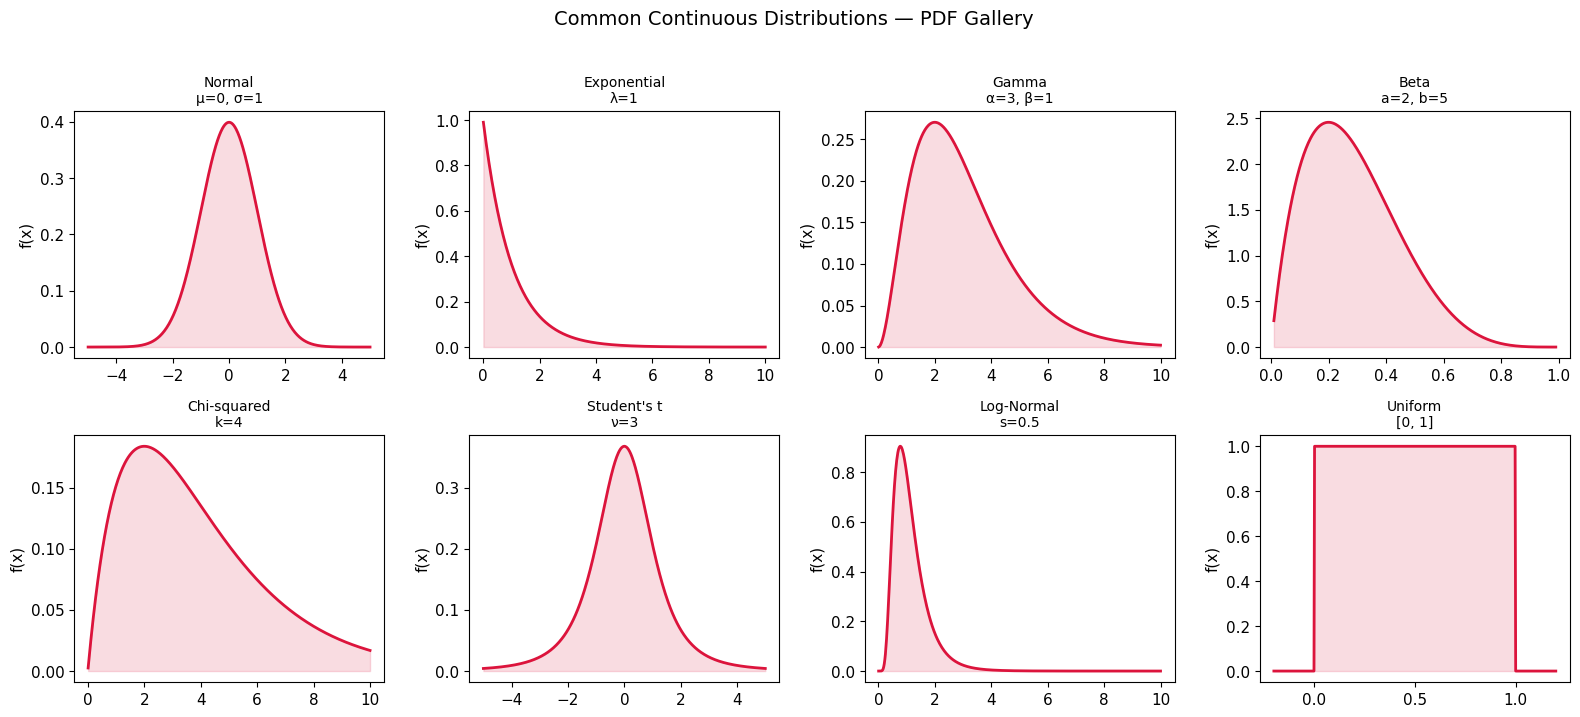

In [5]:
# Visual gallery: PDFs of the most common continuous distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()
x_wide  = np.linspace(-5, 5, 500)
x_pos   = np.linspace(0.01, 10, 500)
x_unit  = np.linspace(0.01, 0.99, 500)

cont_gallery = [
    ('Normal\nμ=0, σ=1',    stats.norm(0, 1),           x_wide),
    ('Exponential\nλ=1',    stats.expon(scale=1),        x_pos),
    ('Gamma\nα=3, β=1',     stats.gamma(a=3, scale=1),   x_pos),
    ('Beta\na=2, b=5',      stats.beta(a=2, b=5),        x_unit),
    ('Chi-squared\nk=4',    stats.chi2(df=4),             x_pos),
    ("Student's t\nν=3",    stats.t(df=3),                x_wide),
    ('Log-Normal\ns=0.5',   stats.lognorm(s=0.5),         x_pos),
    ('Uniform\n[0, 1]',     stats.uniform(0, 1),          np.linspace(-0.2, 1.2, 500)),
]

for ax, (title, rv, xx) in zip(axes, cont_gallery):
    ax.plot(xx, rv.pdf(xx), color='crimson', lw=2)
    ax.fill_between(xx, rv.pdf(xx), alpha=0.15, color='crimson')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('f(x)')

plt.suptitle('Common Continuous Distributions — PDF Gallery', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 3 · Multivariate Distributions

These live directly in `scipy.stats` but do **not** inherit from `rv_continuous` / `rv_discrete`.
Each has its own API; common methods include `.rvs()`, `.pdf()` / `.pmf()`, `.logpdf()`, `.cov()`, `.mean()`.

| # | `scipy.stats` name | Distribution | Key parameters |
|---|---|---|---|
| 1 | `multivariate_normal` | Multivariate Normal | mean, cov |
| 2 | `matrix_normal` | Matrix Normal | mean, rowcov, colcov |
| 3 | `dirichlet` | Dirichlet | alpha |
| 4 | `dirichlet_multinomial` | Dirichlet-Multinomial | alpha, n |
| 5 | `wishart` | Wishart | df, scale |
| 6 | `invwishart` | Inverse Wishart | df, scale |
| 7 | `multinomial` | Multinomial | n, p |
| 8 | `multivariate_hypergeom` | Multivariate Hypergeometric | m, n |
| 9 | `multivariate_t` | Multivariate t | loc, shape, df |
| 10 | `normal_inverse_gamma` | Normal-Inverse-Gamma | loc, variance_scale, shape, scale |
| 11 | `special_ortho_group` | SO(N) — special orthogonal | dim |
| 12 | `ortho_group` | O(N) — orthogonal | dim |
| 13 | `unitary_group` | U(N) — unitary | dim |
| 14 | `random_correlation` | Random correlation matrix | eigs |
| 15 | `random_table` | Random contingency table | row, col |
| 16 | `uniform_direction` | Uniform direction on sphere | dim |
| 17 | `vonmises_fisher` | von Mises–Fisher | mu, kappa |
| 18 | `matrix_t` | Matrix t | — |

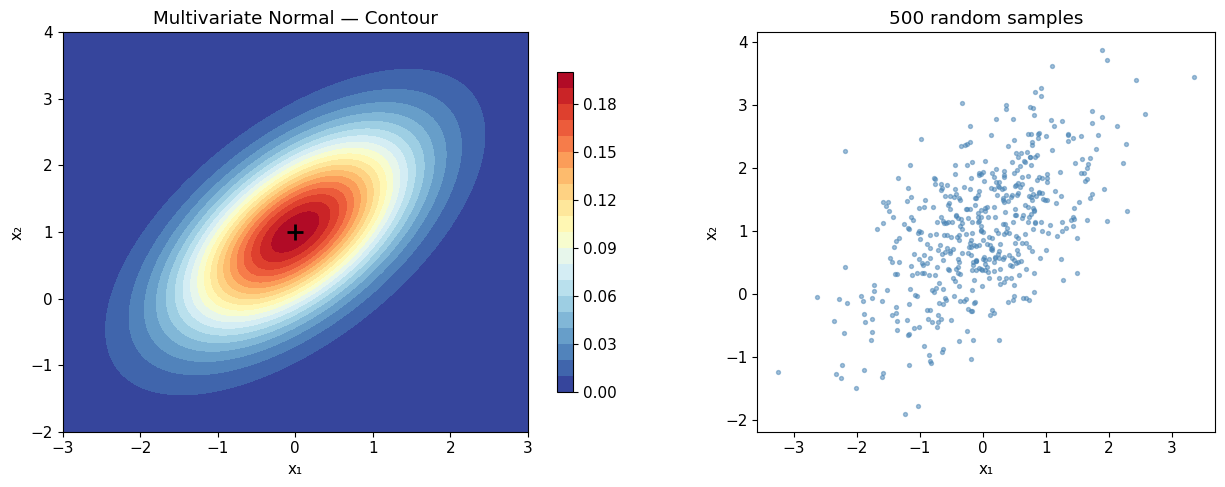

In [6]:
# Multivariate Normal example — the most used multivariate distribution
from scipy.stats import multivariate_normal

mu    = [0, 1]
sigma = [[1.0, 0.6],
         [0.6, 1.0]]

rv = multivariate_normal(mean=mu, cov=sigma)

# Create a grid and evaluate the PDF
x = np.linspace(-3, 3, 200)
y = np.linspace(-2, 4, 200)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
Z = rv.pdf(pos)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Contour plot
cs = axes[0].contourf(X, Y, Z, levels=20, cmap='RdYlBu_r')
fig.colorbar(cs, ax=axes[0], shrink=0.8)
axes[0].set_title('Multivariate Normal — Contour')
axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')
axes[0].plot(*mu, 'k+', ms=12, mew=2)

# Samples scatter
samples = rv.rvs(size=500, random_state=42)
axes[1].scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.5, color='steelblue')
axes[1].set_title('500 random samples')
axes[1].set_xlabel('x₁'); axes[1].set_ylabel('x₂')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

---

## 4 · Working with any distribution: step-by-step

This section shows the **full workflow** using a single distribution. Every `rv_continuous` / `rv_discrete` object supports the same methods.

In [7]:
# Example: Gamma distribution  (shape α=3, rate β=2 → scale=1/β=0.5)
rv = stats.gamma(a=3, scale=0.5)

print("=== Gamma(α=3, β=2) ===")
print(f"Mean      : {rv.mean():.4f}          (expected: α/β = 1.5)")
print(f"Variance  : {rv.var():.4f}           (expected: α/β² = 0.75)")
print(f"Std dev   : {rv.std():.4f}")
print(f"Median    : {rv.median():.4f}")
print(f"Entropy   : {rv.entropy():.4f}")
print()

# PDF & CDF at a point
x0 = 2.0
print(f"pdf({x0})   : {rv.pdf(x0):.6f}")
print(f"cdf({x0})   : {rv.cdf(x0):.6f}      P(X ≤ {x0})")
print(f"sf({x0})    : {rv.sf(x0):.6f}       P(X > {x0})")
print()

# Quantiles
print(f"ppf(0.5)  : {rv.ppf(0.5):.4f}       (median)")
print(f"ppf(0.95) : {rv.ppf(0.95):.4f}       (95th percentile)")
print(f"interval(0.95): {rv.interval(0.95)}   (equal-tail 95% CI)")
print()

# Random samples
samples = rv.rvs(size=5, random_state=0)
print(f"5 samples : {np.round(samples, 4)}")

=== Gamma(α=3, β=2) ===
Mean      : 1.5000          (expected: α/β = 1.5)
Variance  : 0.7500           (expected: α/β² = 0.75)
Std dev   : 0.8660
Median    : 1.3370
Entropy   : 1.1544

pdf(2.0)   : 0.293050
cdf(2.0)   : 0.761897      P(X ≤ 2.0)
sf(2.0)    : 0.238103       P(X > 2.0)

ppf(0.5)  : 1.3370       (median)
ppf(0.95) : 3.1479       (95th percentile)
interval(0.95): (np.float64(0.30933606144780074), np.float64(3.61234383386198))   (equal-tail 95% CI)

5 samples : [3.3546 1.6875 3.5133 0.684  1.2508]


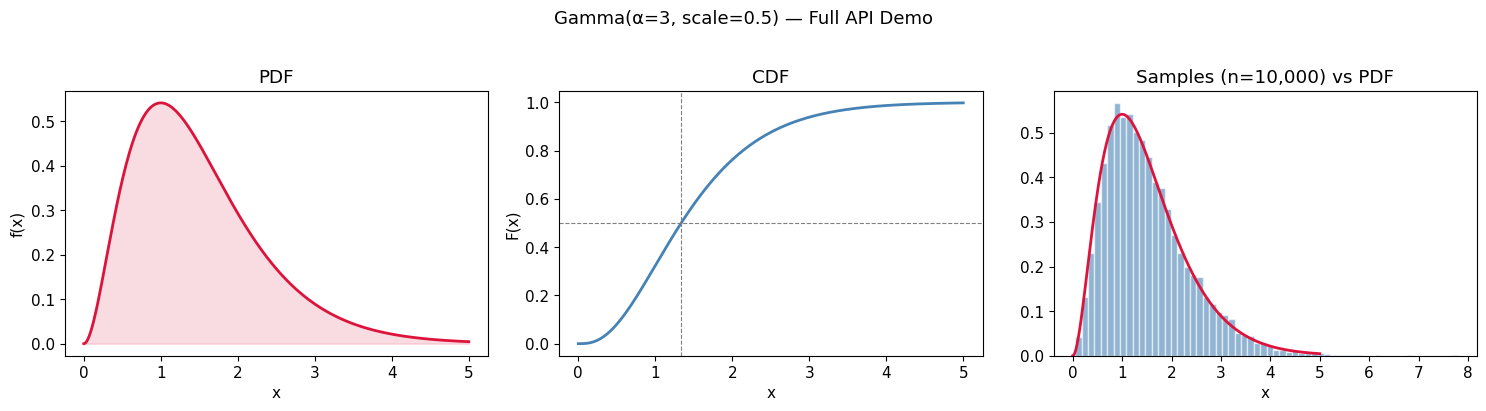

In [8]:
# Visualize PDF, CDF, and a histogram of samples
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.linspace(0, 5, 500)

# PDF
axes[0].plot(x, rv.pdf(x), 'crimson', lw=2)
axes[0].fill_between(x, rv.pdf(x), alpha=0.15, color='crimson')
axes[0].set_title('PDF')
axes[0].set_ylabel('f(x)')

# CDF
axes[1].plot(x, rv.cdf(x), 'steelblue', lw=2)
axes[1].axhline(0.5, ls='--', color='gray', lw=0.8)
axes[1].axvline(rv.median(), ls='--', color='gray', lw=0.8)
axes[1].set_title('CDF')
axes[1].set_ylabel('F(x)')

# Histogram of samples vs PDF
samples = rv.rvs(size=10_000, random_state=42)
axes[2].hist(samples, bins=60, density=True, alpha=0.6, color='steelblue', edgecolor='white')
axes[2].plot(x, rv.pdf(x), 'crimson', lw=2)
axes[2].set_title('Samples (n=10,000) vs PDF')

for ax in axes:
    ax.set_xlabel('x')
plt.suptitle('Gamma(α=3, scale=0.5) — Full API Demo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 5 · Frozen vs Unfrozen distributions

`scipy.stats` distributions can be used in two ways:

```python
# Unfrozen — pass parameters every time
stats.norm.pdf(0, loc=0, scale=1)

# Frozen — bind parameters once, then call methods freely
rv = stats.norm(loc=0, scale=1)
rv.pdf(0)
rv.cdf(1.96)
rv.rvs(size=100)
```

**Frozen** (bound) objects are preferred for readability and efficiency when reusing the same parametrization.

---

## 6 · Fitting a distribution to data

`rv.fit(data)` returns MLE estimates of the shape/loc/scale parameters.

True     : a=4.00, scale=2.00
Estimated: a=4.05, scale=2.01


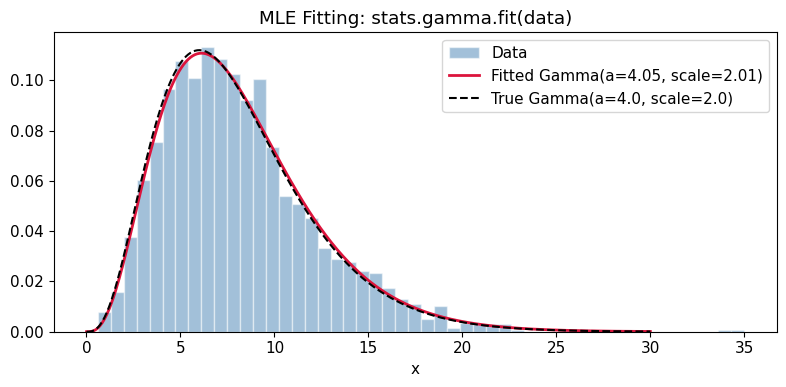

In [9]:
# Generate data from an unknown Gamma, then fit
np.random.seed(42)
true_a, true_scale = 4.0, 2.0
data = stats.gamma.rvs(a=true_a, scale=true_scale, size=2000)

# MLE fit
a_hat, loc_hat, scale_hat = stats.gamma.fit(data, floc=0)  # fix loc=0

print(f"True     : a={true_a:.2f}, scale={true_scale:.2f}")
print(f"Estimated: a={a_hat:.2f}, scale={scale_hat:.2f}")

# Overlay fitted PDF on histogram
x = np.linspace(0, 30, 500)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data, bins=50, density=True, alpha=0.5, color='steelblue', edgecolor='white', label='Data')
ax.plot(x, stats.gamma.pdf(x, a=a_hat, scale=scale_hat), 'crimson', lw=2,
        label=f'Fitted Gamma(a={a_hat:.2f}, scale={scale_hat:.2f})')
ax.plot(x, stats.gamma.pdf(x, a=true_a, scale=true_scale), 'k--', lw=1.5,
        label=f'True Gamma(a={true_a}, scale={true_scale})')
ax.legend()
ax.set_title('MLE Fitting: stats.gamma.fit(data)')
ax.set_xlabel('x')
plt.tight_layout()
plt.show()

---

## 7 · Distribution relationships cheat-sheet

Many distributions are special cases or limits of others:

```
Bernoulli(p)   ──  Binom(1, p)
Binom(n, p)    ──  sum of n Bernoulli(p)
                └─ → Normal(np, np(1-p))            [n large]
                └─ → Poisson(np)                     [n→∞, p→0, np=λ]
Geom(p)        ──  NegBin(1, p)
NegBin(r, p)   ──  sum of r Geom(p)
Hypergeom      ──  → Binom(n, K/N)                  [population N→∞]
Exponential(λ) ──  Gamma(1, λ)
Erlang(k, λ)   ──  Gamma(k, λ)                      [k integer]
                └─ sum of k Exponential(λ)
Chi2(k)        ──  Gamma(k/2, 2)
Normal²        ──  Chi2(1)
Cauchy         ──  t(df=1)
Rayleigh       ──  Weibull_min(c=2, scale=σ√2)
Uniform(0,1)   ──  Beta(1, 1)
```

In [10]:
# Verify some of the relationships above
print("=== Distribution relationships ===\n")

# 1. Bernoulli(p) ≡ Binom(1, p)
p = 0.4
print(f"Bernoulli(0.4).pmf(1) = {stats.bernoulli.pmf(1, p):.4f}")
print(f"Binom(1, 0.4).pmf(1)  = {stats.binom.pmf(1, n=1, p=p):.4f}")
print()

# 2. Binom(n,p) → Poisson(λ=np) when n large, p small
n, p = 1000, 0.005
k = np.arange(0, 15)
print(f"Binom(1000, 0.005) vs Poisson(5):")
print(f"  Binom  pmf(3) = {stats.binom.pmf(3, n, p):.6f}")
print(f"  Poisson pmf(3) = {stats.poisson.pmf(3, mu=n*p):.6f}")
print()

# 3. Exponential(λ=1) ≡ Gamma(1, scale=1)
x0 = 2.0
print(f"Expon(scale=1).pdf(2)    = {stats.expon.pdf(x0, scale=1):.6f}")
print(f"Gamma(a=1, scale=1).pdf(2) = {stats.gamma.pdf(x0, a=1, scale=1):.6f}")
print()

# 4. Chi2(k) ≡ Gamma(k/2, scale=2)
k = 6
x0 = 4.0
print(f"Chi2(df=6).pdf(4)          = {stats.chi2.pdf(x0, df=k):.6f}")
print(f"Gamma(a=3, scale=2).pdf(4) = {stats.gamma.pdf(x0, a=k/2, scale=2):.6f}")
print()

# 5. Uniform(0,1) ≡ Beta(1,1)
x0 = 0.7
print(f"Uniform(0,1).pdf(0.7)  = {stats.uniform.pdf(x0):.6f}")
print(f"Beta(1, 1).pdf(0.7)    = {stats.beta.pdf(x0, a=1, b=1):.6f}")

=== Distribution relationships ===

Bernoulli(0.4).pmf(1) = 0.4000
Binom(1, 0.4).pmf(1)  = 0.4000

Binom(1000, 0.005) vs Poisson(5):
  Binom  pmf(3) = 0.140303
  Poisson pmf(3) = 0.140374

Expon(scale=1).pdf(2)    = 0.135335
Gamma(a=1, scale=1).pdf(2) = 0.135335

Chi2(df=6).pdf(4)          = 0.135335
Gamma(a=3, scale=2).pdf(4) = 0.135335

Uniform(0,1).pdf(0.7)  = 1.000000
Beta(1, 1).pdf(0.7)    = 1.000000


---

## 8 · Quick-lookup: "Which distribution should I use?"

| Scenario | Distribution |
|---|---|
| Yes/no outcome | `bernoulli` |
| Count successes in $n$ trials | `binom` |
| Count successes in $n$ trials, varying $p$ | `betabinom` |
| Trials until first success | `geom` |
| Trials until $r$-th success | `nbinom` |
| Successes when sampling without replacement | `hypergeom` |
| Count of rare events per unit time | `poisson` |
| Waiting time for next event (memoryless) | `expon` |
| Waiting time for $k$-th event | `gamma` / `erlang` |
| Proportion / probability parameter | `beta` |
| Real-valued measurement, symmetric | `norm` |
| Right-skewed positive data | `lognorm`, `gamma`, `weibull_min` |
| Heavy-tailed symmetric data | `t`, `cauchy` |
| Test statistic (sum of squared normals) | `chi2` |
| Ratio of variances | `f` |
| Small-sample mean testing | `t` |
| Bounded continuous data $[a,b]$ | `uniform`, `triang`, `beta` |
| Direction / angle data | `vonmises` |
| Correlated multivariate data | `multivariate_normal` |
| Categorical outcomes | `multinomial` |